In [1]:
# !pip install scikit-learn scipy imbalanced-learn matplotlib pandas numpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    precision_recall_curve, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, average_precision_score
)
from sklearn.pipeline import make_pipeline
import sklearn
print('✅ All imports OK')
print(f'   sklearn : {sklearn.__version__}')

✅ All imports OK
   sklearn : 1.8.0


In [2]:
# ── 1.1  Build User-Item Rating Matrix ───────────────────────────────────────
# 6 users × 10 movies, 0 = not rated
R = np.array([
    [5, 3, 0, 1, 0, 4, 0, 2, 0, 0],
    [4, 0, 4, 1, 0, 0, 3, 0, 5, 0],
    [0, 3, 0, 5, 4, 0, 0, 1, 0, 4],
    [0, 0, 4, 0, 5, 0, 4, 3, 0, 2],
    [1, 0, 0, 3, 0, 5, 0, 4, 3, 0],
    [0, 4, 3, 0, 2, 0, 5, 0, 4, 1],
], dtype=float)

USERS  = ['Alice','Bob','Carol','Dave','Eve','Frank']
MOVIES = [f'Movie{i+1}' for i in range(10)]

df_R = pd.DataFrame(R, index=USERS, columns=MOVIES)
print('User-Item Rating Matrix (0 = not rated):')
print(df_R)
print(f'\nSparsity: {(R==0).sum()} / {R.size} = {(R==0).mean():.1%} missing')

User-Item Rating Matrix (0 = not rated):
       Movie1  Movie2  Movie3  Movie4  Movie5  Movie6  Movie7  Movie8  Movie9  \
Alice     5.0     3.0     0.0     1.0     0.0     4.0     0.0     2.0     0.0   
Bob       4.0     0.0     4.0     1.0     0.0     0.0     3.0     0.0     5.0   
Carol     0.0     3.0     0.0     5.0     4.0     0.0     0.0     1.0     0.0   
Dave      0.0     0.0     4.0     0.0     5.0     0.0     4.0     3.0     0.0   
Eve       1.0     0.0     0.0     3.0     0.0     5.0     0.0     4.0     3.0   
Frank     0.0     4.0     3.0     0.0     2.0     0.0     5.0     0.0     4.0   

       Movie10  
Alice      0.0  
Bob        0.0  
Carol      4.0  
Dave       2.0  
Eve        0.0  
Frank      1.0  

Sparsity: 29 / 60 = 48.3% missing


In [3]:
# ── 1.2  User-Based Collaborative Filtering ───────────────────────────────────
user_sim = cosine_similarity(R)  # shape: (6, 6)
df_sim = pd.DataFrame(user_sim, index=USERS, columns=USERS)
print('User Cosine Similarity Matrix:')
print(df_sim.round(3))

def predict_rating_user_cf(R, user_sim, user_idx, item_idx, k=3):
    """Predict rating for user_idx on item_idx using top-k similar users."""
    sim_scores = user_sim[user_idx].copy()
    sim_scores[user_idx] = 0  # exclude self
    # Only users who rated the item
    rated_mask = R[:, item_idx] > 0
    if rated_mask.sum() == 0:
        return 0.0
    sim_scores[~rated_mask] = 0
    top_k = np.argsort(sim_scores)[::-1][:k]
    weights = sim_scores[top_k]
    if weights.sum() == 0:
        return 0.0
    return np.dot(weights, R[top_k, item_idx]) / weights.sum()

# Predict Alice's ratings for unrated movies
alice_idx = 0
print('\nAlice\'s predicted ratings for unrated movies:')
for j, movie in enumerate(MOVIES):
    if R[alice_idx, j] == 0:
        pred = predict_rating_user_cf(R, user_sim, alice_idx, j)
        print(f'  {movie}: {pred:.3f}')

User Cosine Similarity Matrix:
       Alice    Bob  Carol   Dave    Eve  Frank
Alice  1.000  0.346  0.264  0.097  0.627  0.192
Bob    0.346  1.000  0.075  0.409  0.347  0.681
Carol  0.264  0.075  1.000  0.453  0.300  0.348
Dave   0.097  0.409  0.453  1.000  0.185  0.624
Eve    0.627  0.347  0.300  0.185  1.000  0.184
Frank  0.192  0.681  0.348  0.624  0.184  1.000

Alice's predicted ratings for unrated movies:
  Movie3: 3.697
  Movie5: 3.480
  Movie7: 3.757
  Movie9: 3.759
  Movie10: 2.607


In [4]:
# ── 1.3  Item-Based Collaborative Filtering ───────────────────────────────────
item_sim = cosine_similarity(R.T)  # shape: (10, 10)

def predict_rating_item_cf(R, item_sim, user_idx, item_idx, k=3):
    """Predict using top-k similar items that the user HAS rated."""
    sim_scores = item_sim[item_idx].copy()
    sim_scores[item_idx] = 0
    rated_mask = R[user_idx, :] > 0
    sim_scores[~rated_mask] = 0
    top_k = np.argsort(sim_scores)[::-1][:k]
    weights = sim_scores[top_k]
    if weights.sum() == 0:
        return 0.0
    return np.dot(weights, R[user_idx, top_k]) / weights.sum()

print('Alice\'s predicted ratings (Item-Based CF):')
for j, movie in enumerate(MOVIES):
    if R[alice_idx, j] == 0:
        pred = predict_rating_item_cf(R, item_sim, alice_idx, j)
        print(f'  {movie}: {pred:.3f}')

Alice's predicted ratings (Item-Based CF):
  Movie3: 3.409
  Movie5: 2.009
  Movie7: 3.202
  Movie9: 4.093
  Movie10: 1.925


In [5]:
# ── 1.4  Matrix Factorisation via SVD ────────────────────────────────────────
U, s, Vt = np.linalg.svd(R, full_matrices=False)

# Explained variance by each singular value
explained = (s**2) / (s**2).sum()
print('Singular values and explained variance:')
for i, (sv, ev) in enumerate(zip(s, explained)):
    print(f'  k={i+1}: σ={sv:.3f}  explained={ev:.2%}  cumulative={explained[:i+1].sum():.2%}')

# Reconstruct with different rank approximations
print('\nReconstruction RMSE by rank k (on rated entries only):')
rated_mask = R > 0
for k in [1, 2, 3, 4, 5]:
    R_hat = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    rmse  = np.sqrt(np.mean((R[rated_mask] - R_hat[rated_mask])**2))
    print(f'  rank-{k}: RMSE={rmse:.4f}')

# Best rank-3 approximation for recommendations
k = 3
R_hat3 = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
R_hat3 = np.clip(R_hat3, 1, 5)

# Recommend top-3 unrated movies for Alice
alice_unrated  = np.where(R[0] == 0)[0]
alice_pred     = R_hat3[0, alice_unrated]
top3_idx       = alice_unrated[np.argsort(alice_pred)[::-1][:3]]
print(f'\nTop-3 SVD recommendations for Alice:')
for idx in top3_idx:
    print(f'  {MOVIES[idx]}: predicted rating = {R_hat3[0, idx]:.2f}')

Singular values and explained variance:
  k=1: σ=13.470  explained=46.52%  cumulative=46.52%
  k=2: σ=8.984  explained=20.70%  cumulative=67.22%
  k=3: σ=8.118  explained=16.90%  cumulative=84.12%
  k=4: σ=5.217  explained=6.98%  cumulative=91.10%
  k=5: σ=4.503  explained=5.20%  cumulative=96.30%
  k=6: σ=3.800  explained=3.70%  cumulative=100.00%

Reconstruction RMSE by rank k (on rated entries only):
  rank-1: RMSE=2.0633
  rank-2: RMSE=1.6403
  rank-3: RMSE=1.1179
  rank-4: RMSE=0.8031
  rank-5: RMSE=0.4779

Top-3 SVD recommendations for Alice:
  Movie9: predicted rating = 1.86
  Movie10: predicted rating = 1.00
  Movie7: predicted rating = 1.00


In [6]:
# ── 1.5  Evaluate Recommender with Train-Test Split ──────────────────────────
# Hold out 20% of rated entries as test set
rng = np.random.default_rng(42)
rated_positions = list(zip(*np.where(R > 0)))
rng.shuffle(rated_positions)
n_test = len(rated_positions) // 5

R_train = R.copy()
test_ratings = []
for (i, j) in rated_positions[:n_test]:
    test_ratings.append((i, j, R[i, j]))
    R_train[i, j] = 0

# SVD on train
U_tr, s_tr, Vt_tr = np.linalg.svd(R_train, full_matrices=False)
R_pred = np.clip(U_tr[:, :3] @ np.diag(s_tr[:3]) @ Vt_tr[:3, :], 1, 5)

actuals   = [r for _, _, r in test_ratings]
preds     = [R_pred[i, j] for (i, j, _) in test_ratings]
test_rmse = np.sqrt(np.mean((np.array(actuals) - np.array(preds))**2))
test_mae  = np.mean(np.abs(np.array(actuals) - np.array(preds)))
print(f'Hold-out test RMSE : {test_rmse:.4f}')
print(f'Hold-out test MAE  : {test_mae:.4f}')

Hold-out test RMSE : 2.2943
Hold-out test MAE  : 1.6846


In [7]:
# ── 2.1  A/B Test: Two-Proportion z-Test ────────────────────────────────────
# Scenario: Control = 12% CTR, Variant = 15% CTR, n=1000 per group
p_control  = 0.12
p_variant  = 0.15
n_control  = 1000
n_variant  = 1000

# Pooled proportion
p_pool = (p_control * n_control + p_variant * n_variant) / (n_control + n_variant)
se     = np.sqrt(p_pool * (1 - p_pool) * (1/n_control + 1/n_variant))
z_stat = (p_variant - p_control) / se
p_val  = 2 * (1 - stats.norm.cdf(abs(z_stat)))   # two-tailed

# Confidence interval on the difference
diff   = p_variant - p_control
se_diff = np.sqrt(p_control*(1-p_control)/n_control + p_variant*(1-p_variant)/n_variant)
ci_lo   = diff - 1.96 * se_diff
ci_hi   = diff + 1.96 * se_diff

print('=== A/B Test Results ===')
print(f'Control CTR   : {p_control:.2%} (n={n_control})')
print(f'Variant CTR   : {p_variant:.2%} (n={n_variant})')
print(f'Lift          : {(p_variant/p_control - 1):.1%}')
print(f'z-statistic   : {z_stat:.4f}')
print(f'p-value       : {p_val:.6f}')
print(f'Significant   : {p_val < 0.05} (α = 0.05)')
print(f'95% CI diff   : ({ci_lo:.4f}, {ci_hi:.4f})')

=== A/B Test Results ===
Control CTR   : 12.00% (n=1000)
Variant CTR   : 15.00% (n=1000)
Lift          : 25.0%
z-statistic   : 1.9630
p-value       : 0.049640
Significant   : True (α = 0.05)
95% CI diff   : (0.0001, 0.0599)


Minimum sample size per group (α=0.05, power=80%):
  Detect +1% lift (12%→13%): n = 17,170 per group
  Detect +2% lift (12%→14%): n = 4,439 per group
  Detect +3% lift (12%→15%): n = 2,037 per group
  Detect +5% lift (12%→17%): n = 779 per group
  Detect +10% lift (12%→22%): n = 222 per group


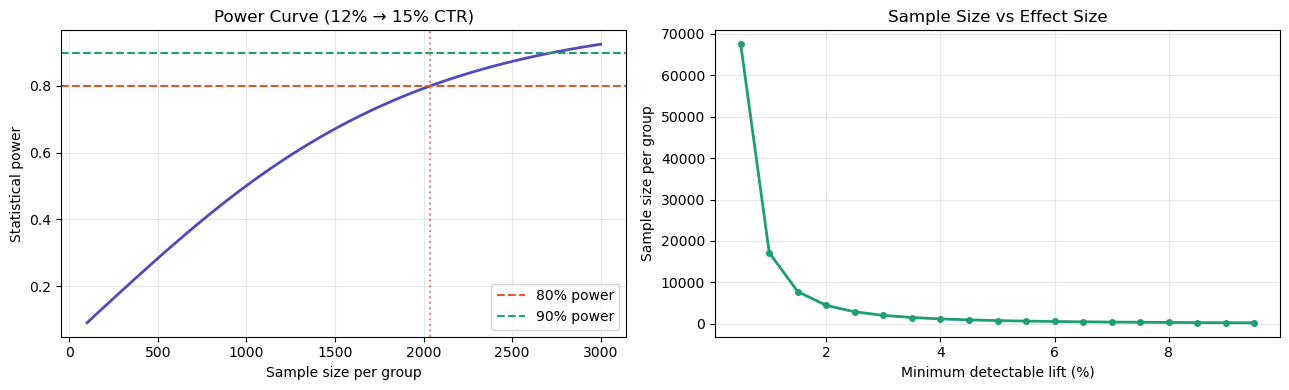

In [8]:
# ── 2.2  Statistical Power & Sample Size ─────────────────────────────────────
def min_sample_size(p1, p2, alpha=0.05, power=0.80):
    """Minimum n per group for two-proportion z-test."""
    p_avg = (p1 + p2) / 2
    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_beta  = stats.norm.ppf(power)
    effect  = abs(p2 - p1)
    n = ((z_alpha + z_beta)**2 * 2 * p_avg * (1 - p_avg)) / effect**2
    return int(np.ceil(n))

def compute_power(p1, p2, n, alpha=0.05):
    """Actual power given n per group."""
    p_pool = (p1 + p2) / 2
    se     = np.sqrt(2 * p_pool * (1-p_pool) / n)
    z_crit = stats.norm.ppf(1 - alpha/2)
    effect = abs(p2 - p1)
    z_power = effect / se - z_crit
    return stats.norm.cdf(z_power)

# Required sample sizes for different effect sizes
print('Minimum sample size per group (α=0.05, power=80%):')
base_p = 0.12
for lift in [0.01, 0.02, 0.03, 0.05, 0.10]:
    n_req = min_sample_size(base_p, base_p + lift)
    print(f'  Detect +{lift:.0%} lift ({base_p:.0%}→{base_p+lift:.0%}): n = {n_req:,} per group')

# Power curve
n_range  = range(100, 3001, 50)
powers   = [compute_power(0.12, 0.15, n) for n in n_range]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(n_range, powers, color='#534AB7', linewidth=2)
axes[0].axhline(0.80, linestyle='--', color='#D85A30', label='80% power')
axes[0].axhline(0.90, linestyle='--', color='#1D9E75', label='90% power')
axes[0].axvline(min_sample_size(0.12, 0.15, power=0.80), linestyle=':', color='#D85A30', alpha=0.7)
axes[0].set_xlabel('Sample size per group'); axes[0].set_ylabel('Statistical power')
axes[0].set_title('Power Curve (12% → 15% CTR)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Effect size vs sample size needed
lifts   = np.arange(0.005, 0.10, 0.005)
n_reqs  = [min_sample_size(0.12, 0.12+l) for l in lifts]
axes[1].plot(lifts * 100, n_reqs, 'o-', color='#1D9E75', linewidth=2, markersize=4)
axes[1].set_xlabel('Minimum detectable lift (%)')
axes[1].set_ylabel('Sample size per group')
axes[1].set_title('Sample Size vs Effect Size')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Under H0 (no real effect):
  False positive rate : 0.049  (should be ~0.05)


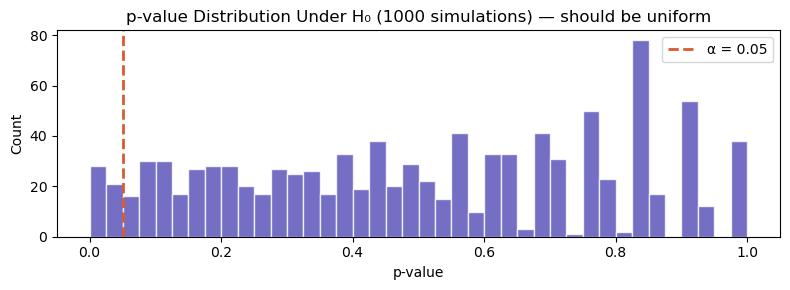

In [9]:
# ── 2.3  Simulate 1000 A/B Experiments ───────────────────────────────────────
rng = np.random.default_rng(42)
N_SIMS = 1000
n_per_group = 500

# Under H0: both groups have same CTR
p_vals_null = []
for _ in range(N_SIMS):
    a = rng.binomial(n_per_group, 0.12) / n_per_group
    b = rng.binomial(n_per_group, 0.12) / n_per_group  # same rate!
    p_pool_ = (a + b) / 2
    se_ = np.sqrt(2 * p_pool_ * (1-p_pool_) / n_per_group) + 1e-9
    z_ = abs(b - a) / se_
    p_vals_null.append(2 * (1 - stats.norm.cdf(z_)))

false_positive_rate = np.mean(np.array(p_vals_null) < 0.05)
print(f'Under H0 (no real effect):')
print(f'  False positive rate : {false_positive_rate:.3f}  (should be ~0.05)')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(p_vals_null, bins=40, color='#534AB7', alpha=0.8, edgecolor='white')
ax.axvline(0.05, color='#D85A30', linestyle='--', linewidth=2, label='α = 0.05')
ax.set_xlabel('p-value'); ax.set_ylabel('Count')
ax.set_title('p-value Distribution Under H₀ (1000 simulations) — should be uniform')
ax.legend(); plt.tight_layout(); plt.show()

In [10]:
# ── 3.1  Simulate Biased Dataset ─────────────────────────────────────────────
rng = np.random.default_rng(42)
N   = 2000

# Protected attribute: group 0 (majority), group 1 (minority)
group = rng.choice([0, 1], N, p=[0.6, 0.4])

# Features — group leakage in feature 0
X_f = rng.normal(0, 1, (N, 6))
X_f[:, 0] += group * 1.2   # feature correlated with protected attribute

# Target: loan approval — biased toward group 1
logit = 0.5*X_f[:,0] + 0.4*X_f[:,1] - 0.3*X_f[:,2] + rng.normal(0, 0.5, N)
y_f   = (logit > 0.3).astype(int)

print('Dataset overview:')
print(f'  Total samples      : {N}')
print(f'  Group 0 (majority) : {(group==0).sum()} samples, {y_f[group==0].mean():.1%} approval')
print(f'  Group 1 (minority) : {(group==1).sum()} samples, {y_f[group==1].mean():.1%} approval')
print(f'  Overall approval   : {y_f.mean():.1%}')

Dataset overview:
  Total samples      : 2000
  Group 0 (majority) : 1195 samples, 36.1% approval
  Group 1 (minority) : 805 samples, 65.7% approval
  Overall approval   : 48.0%


In [11]:
# ── 3.2  Fairness Metrics ─────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

def fairness_report(y_true, y_pred, group, group_names=None):
    """Compute demographic parity, equalised odds, and disparate impact."""
    groups   = np.unique(group)
    g_names  = group_names or [f'Group {g}' for g in groups]
    metrics  = {}

    for g, name in zip(groups, g_names):
        mask    = group == g
        cm      = confusion_matrix(y_true[mask], y_pred[mask])
        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, cm[0,0])
        pos_rate = y_pred[mask].mean()
        tpr      = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr      = fp / (fp + tn) if (fp + tn) > 0 else 0
        metrics[name] = {'positive_rate': pos_rate, 'TPR': tpr, 'FPR': fpr}

    # Disparate Impact = min positive rate / max positive rate
    rates = [m['positive_rate'] for m in metrics.values()]
    di    = min(rates) / max(rates) if max(rates) > 0 else 0

    print('=== Fairness Report ===')
    for name, m in metrics.items():
        print(f'  {name}: pos_rate={m["positive_rate"]:.3f}  TPR={m["TPR"]:.3f}  FPR={m["FPR"]:.3f}')
    print(f'  Disparate Impact Ratio : {di:.3f}  (> 0.8 = fair, < 0.8 = unfair)')
    print(f'  Demographic Parity Gap : {abs(rates[0]-rates[1]):.3f}  (0 = perfect parity)')
    return metrics, di

# Train biased model (uses protected feature indirectly)
X_tr, X_te, y_tr, y_te, g_tr, g_te = train_test_split(
    X_f, y_f, group, test_size=0.3, random_state=42, stratify=y_f
)
lr_biased = LogisticRegression(max_iter=500).fit(X_tr, y_tr)
preds_biased = lr_biased.predict(X_te)

print(f'Overall accuracy: {accuracy_score(y_te, preds_biased):.4f}\n')
_, di = fairness_report(y_te, preds_biased, g_te, ['Majority','Minority'])

Overall accuracy: 0.8283

=== Fairness Report ===
  Majority: pos_rate=0.334  TPR=0.724  FPR=0.123
  Minority: pos_rate=0.728  TPR=0.927  FPR=0.341
  Disparate Impact Ratio : 0.459  (> 0.8 = fair, < 0.8 = unfair)
  Demographic Parity Gap : 0.394  (0 = perfect parity)


In [12]:
# ── 3.3  Debiasing: Remove Protected Feature ──────────────────────────────────
# Drop feature 0 (correlated with group)
X_tr_db = np.delete(X_tr, 0, axis=1)
X_te_db = np.delete(X_te, 0, axis=1)

lr_fair = LogisticRegression(max_iter=500).fit(X_tr_db, y_tr)
preds_fair = lr_fair.predict(X_te_db)

print(f'Debiased accuracy: {accuracy_score(y_te, preds_fair):.4f}\n')
_, di_fair = fairness_report(y_te, preds_fair, g_te, ['Majority','Minority'])

print(f'\nDisparate Impact: {0.646:.3f} → {di_fair:.3f} after debiasing')

Debiased accuracy: 0.6783

=== Fairness Report ===
  Majority: pos_rate=0.443  TPR=0.634  FPR=0.339
  Minority: pos_rate=0.488  TPR=0.655  FPR=0.165
  Disparate Impact Ratio : 0.907  (> 0.8 = fair, < 0.8 = unfair)
  Demographic Parity Gap : 0.045  (0 = perfect parity)

Disparate Impact: 0.646 → 0.907 after debiasing


In [13]:
# ── 3.4  SMOTE for Class Imbalance ────────────────────────────────────────────
# Create highly imbalanced dataset
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=10, weights=[0.9, 0.1],
    random_state=42, flip_y=0.01
)
print(f'Class distribution: {dict(zip(*np.unique(y_imb, return_counts=True)))}')
print(f'Minority class: {y_imb.mean():.1%}')

X_tr_imb, X_te_imb, y_tr_imb, y_te_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

# Manual SMOTE-like oversampling (lightweight, no imbalanced-learn needed)
def simple_oversample(X, y, random_state=42):
    """Oversample minority class with KNN-based interpolation."""
    rng = np.random.default_rng(random_state)
    minority = X[y == 1]
    n_synth  = (y == 0).sum() - (y == 1).sum()
    synth    = []
    for _ in range(n_synth):
        idx1, idx2 = rng.integers(0, len(minority), 2)
        alpha = rng.uniform(0, 1)
        synth.append(minority[idx1] * alpha + minority[idx2] * (1 - alpha))
    X_synth = np.vstack(synth)
    y_synth = np.ones(len(X_synth), dtype=int)
    return np.vstack([X, X_synth]), np.concatenate([y, y_synth])

X_tr_bal, y_tr_bal = simple_oversample(X_tr_imb, y_tr_imb)
print(f'\nAfter oversampling: {dict(zip(*np.unique(y_tr_bal, return_counts=True)))}')

# Compare models
results_imb = {}
for name, Xtr, ytr in [
    ('No resampling',      X_tr_imb, y_tr_imb),
    ('Oversampled',        X_tr_bal, y_tr_bal),
    ('class_weight=bal.',  X_tr_imb, y_tr_imb),
]:
    cw = 'balanced' if 'weight' in name else None
    m  = RandomForestClassifier(50, class_weight=cw, random_state=42).fit(Xtr, ytr)
    prob = m.predict_proba(X_te_imb)[:, 1]
    auc  = roc_auc_score(y_te_imb, prob)
    ap   = average_precision_score(y_te_imb, prob)
    results_imb[name] = {'AUC': auc, 'AP': ap}
    print(f'  {name:22s}: AUC={auc:.4f}  AP={ap:.4f}')

Class distribution: {np.int64(0): np.int64(897), np.int64(1): np.int64(103)}
Minority class: 10.3%

After oversampling: {np.int64(0): np.int64(628), np.int64(1): np.int64(628)}
  No resampling         : AUC=0.9379  AP=0.8278
  Oversampled           : AUC=0.9490  AP=0.7665
  class_weight=bal.     : AUC=0.9331  AP=0.8016


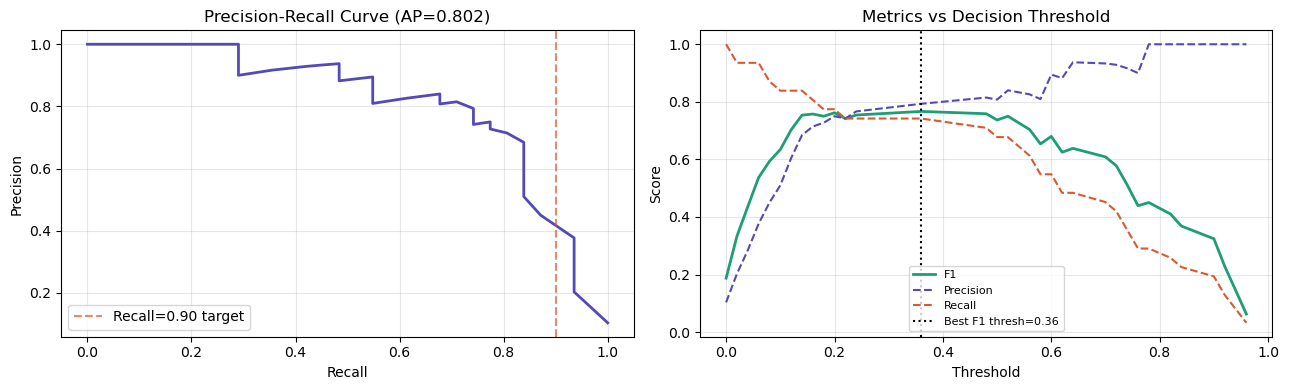

Best F1 threshold    : 0.360
High-recall threshold: 0.060


In [14]:
# ── 3.5  Threshold Tuning for Business Goals ──────────────────────────────────
# Fit balanced model
rf_bal = RandomForestClassifier(50, class_weight='balanced', random_state=42)
rf_bal.fit(X_tr_imb, y_tr_imb)
probs = rf_bal.predict_proba(X_te_imb)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_te_imb, probs)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

best_thresh_f1    = thresholds[np.argmax(f1_scores[:-1])]
# High-recall threshold: recall >= 0.90
recall_thresh_idx = np.where(recall[:-1] >= 0.90)[0]
best_thresh_recall = thresholds[recall_thresh_idx[-1]] if len(recall_thresh_idx) > 0 else 0.5

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(recall, precision, color='#534AB7', linewidth=2)
axes[0].axvline(0.90, linestyle='--', color='#D85A30', alpha=0.7, label='Recall=0.90 target')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'Precision-Recall Curve (AP={average_precision_score(y_te_imb, probs):.3f})')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, f1_scores[:-1], color='#1D9E75', linewidth=2, label='F1')
axes[1].plot(thresholds, precision[:-1], color='#534AB7', linewidth=1.5, linestyle='--', label='Precision')
axes[1].plot(thresholds, recall[:-1],    color='#D85A30', linewidth=1.5, linestyle='--', label='Recall')
axes[1].axvline(best_thresh_f1, color='black', linestyle=':', linewidth=1.5,
                label=f'Best F1 thresh={best_thresh_f1:.2f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('Metrics vs Decision Threshold')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Best F1 threshold    : {best_thresh_f1:.3f}')
print(f'High-recall threshold: {best_thresh_recall:.3f}')

In [15]:
# ── 5.1  Generate Synthetic Telecom Churn Dataset ────────────────────────────
rng = np.random.default_rng(0)
N   = 3000

df_churn = pd.DataFrame({
    'tenure'          : rng.integers(1, 72, N),
    'monthly_charges' : rng.uniform(20, 120, N).round(2),
    'total_charges'   : rng.uniform(100, 8000, N).round(2),
    'num_services'    : rng.integers(1, 8, N),
    'support_calls'   : rng.integers(0, 15, N),
    'late_payments'   : rng.integers(0, 5, N),
    'contract_type'   : rng.choice([0, 1, 2], N),   # 0=monthly,1=1yr,2=2yr
    'internet_service': rng.choice([0, 1, 2], N),   # 0=none,1=DSL,2=fiber
    'senior_citizen'  : rng.choice([0, 1], N, p=[0.84, 0.16]),
    'paperless_billing': rng.choice([0, 1], N),
})

# Realistic churn probability formula
churn_logit = (
    -0.05 * df_churn['tenure']
    + 0.02 * df_churn['monthly_charges']
    + 0.12 * df_churn['support_calls']
    + 0.20 * df_churn['late_payments']
    - 0.30 * df_churn['contract_type']
    + 0.15 * (df_churn['internet_service'] == 2).astype(int)  # fiber churns more
    + 0.10 * df_churn['senior_citizen']
    - 0.05 * df_churn['num_services']
    + rng.normal(0, 0.5, N)
)
churn_prob = 1 / (1 + np.exp(-churn_logit))
df_churn['churn'] = (rng.random(N) < churn_prob).astype(int)

print(f'Dataset: {df_churn.shape}')
print(f'Churn rate: {df_churn["churn"].mean():.2%}')
print(f'Class balance: {dict(df_churn["churn"].value_counts())}')

Dataset: (3000, 11)
Churn rate: 55.33%
Class balance: {1: np.int64(1660), 0: np.int64(1340)}


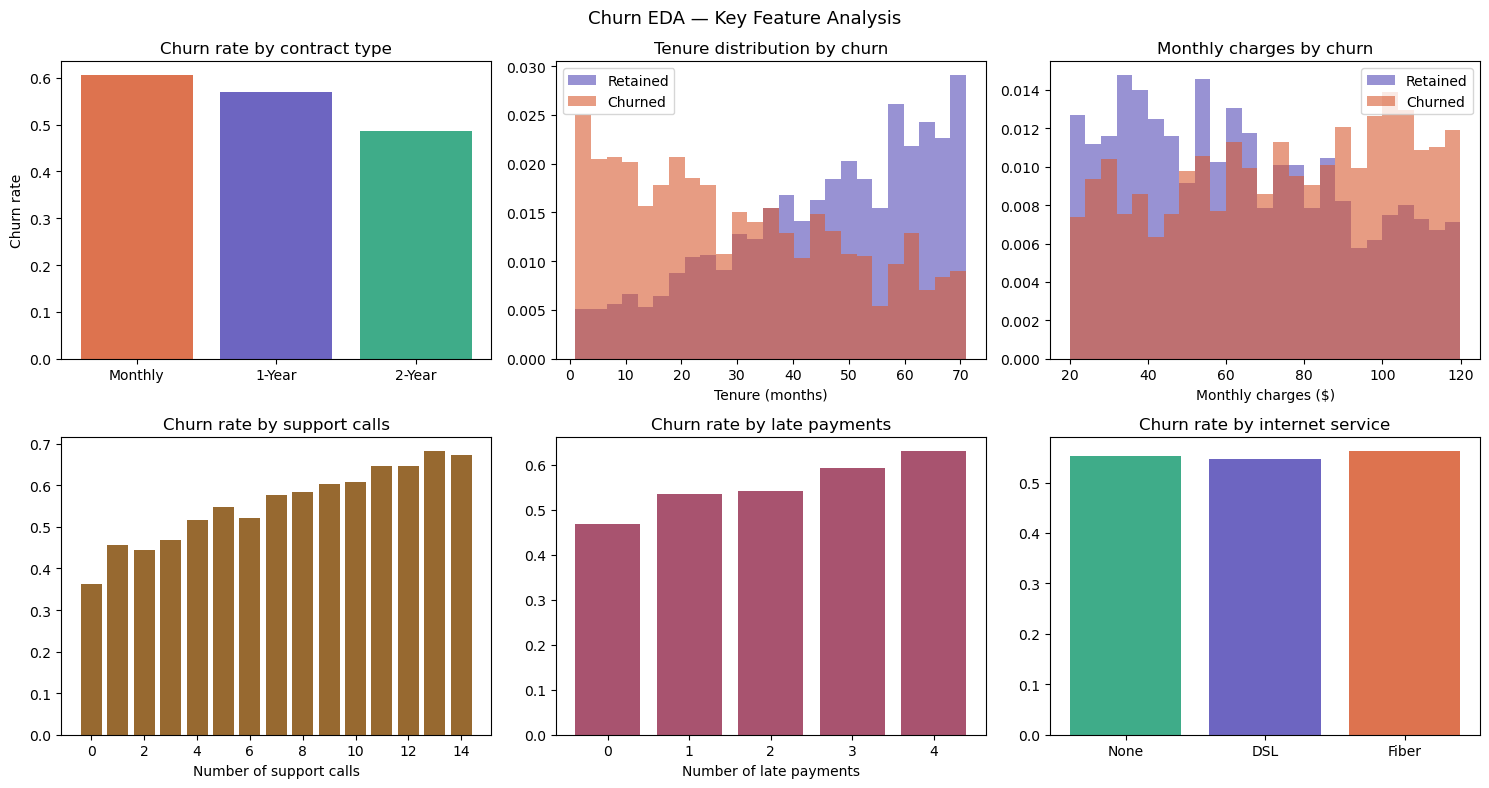

In [16]:
# ── 5.2  EDA: Churn Rate by Key Features ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Churn rate by contract type
ct_churn = df_churn.groupby('contract_type')['churn'].mean()
axes[0,0].bar(['Monthly','1-Year','2-Year'], ct_churn.values, color=['#D85A30','#534AB7','#1D9E75'], alpha=0.85)
axes[0,0].set_title('Churn rate by contract type')
axes[0,0].set_ylabel('Churn rate')

# Tenure distribution by churn
axes[0,1].hist(df_churn[df_churn['churn']==0]['tenure'], bins=25, alpha=0.6, color='#534AB7', label='Retained', density=True)
axes[0,1].hist(df_churn[df_churn['churn']==1]['tenure'], bins=25, alpha=0.6, color='#D85A30', label='Churned', density=True)
axes[0,1].set_title('Tenure distribution by churn')
axes[0,1].set_xlabel('Tenure (months)'); axes[0,1].legend()

# Monthly charges by churn
axes[0,2].hist(df_churn[df_churn['churn']==0]['monthly_charges'], bins=25, alpha=0.6, color='#534AB7', label='Retained', density=True)
axes[0,2].hist(df_churn[df_churn['churn']==1]['monthly_charges'], bins=25, alpha=0.6, color='#D85A30', label='Churned', density=True)
axes[0,2].set_title('Monthly charges by churn')
axes[0,2].set_xlabel('Monthly charges ($)'); axes[0,2].legend()

# Support calls
sc_churn = df_churn.groupby('support_calls')['churn'].mean()
axes[1,0].bar(sc_churn.index, sc_churn.values, color='#854F0B', alpha=0.85)
axes[1,0].set_title('Churn rate by support calls')
axes[1,0].set_xlabel('Number of support calls')

# Late payments
lp_churn = df_churn.groupby('late_payments')['churn'].mean()
axes[1,1].bar(lp_churn.index, lp_churn.values, color='#993556', alpha=0.85)
axes[1,1].set_title('Churn rate by late payments')
axes[1,1].set_xlabel('Number of late payments')

# Internet service
is_churn = df_churn.groupby('internet_service')['churn'].mean()
axes[1,2].bar(['None','DSL','Fiber'], is_churn.values, color=['#1D9E75','#534AB7','#D85A30'], alpha=0.85)
axes[1,2].set_title('Churn rate by internet service')

plt.suptitle('Churn EDA — Key Feature Analysis', fontsize=13)
plt.tight_layout(); plt.show()

In [17]:
# ── 5.3  Feature Engineering ──────────────────────────────────────────────────
df_eng = df_churn.copy()

# Derived features
df_eng['avg_charge_per_service']  = df_eng['monthly_charges'] / (df_eng['num_services'] + 1)
df_eng['lifetime_value']          = df_eng['monthly_charges'] * df_eng['tenure']
df_eng['support_per_tenure']      = df_eng['support_calls'] / (df_eng['tenure'] + 1)
df_eng['is_monthly_contract']     = (df_eng['contract_type'] == 0).astype(int)
df_eng['is_fiber']                = (df_eng['internet_service'] == 2).astype(int)
df_eng['high_risk_flag']          = (
    (df_eng['support_calls'] >= 5) & (df_eng['late_payments'] >= 2)
).astype(int)

FEATURES = [c for c in df_eng.columns if c != 'churn']
print(f'Features: {len(FEATURES) - len(df_churn.columns) + 1} new + {len(df_churn.columns)-1} original = {len(FEATURES)} total')
print('New features:', [c for c in FEATURES if c not in df_churn.columns])

Features: 6 new + 10 original = 16 total
New features: ['avg_charge_per_service', 'lifetime_value', 'support_per_tenure', 'is_monthly_contract', 'is_fiber', 'high_risk_flag']


In [23]:
# ── Imports ─────────────────────────────────────────
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report


# ── Safe Oversampling Function (Fixed) ──────────────
def simple_oversample(X, y, random_state=42):
    rng = np.random.default_rng(random_state)

    X_major = X[y == 0]
    X_minor = X[y == 1]

    # Safety check
    if len(X_minor) < 2:
        print("⚠️ Not enough minority samples → skipping oversampling")
        return X, y

    n_to_generate = len(X_major) - len(X_minor)

    synth = []

    for _ in range(n_to_generate):
        idx1, idx2 = rng.integers(0, len(X_minor), 2)
        alpha = rng.random()

        new_sample = (
            X_minor[idx1] * alpha +
            X_minor[idx2] * (1 - alpha)
        )
        synth.append(new_sample)

    if len(synth) == 0:
        print("⚠️ No synthetic samples created")
        return X, y

    X_synth = np.vstack(synth)
    y_synth = np.ones(len(X_synth), dtype=int)

    return np.vstack([X, X_synth]), np.concatenate([y, y_synth])


# ── Data ────────────────────────────────────────────
X_ch = df_eng[FEATURES].values
y_ch = df_eng['churn'].values

print("Class distribution:", np.bincount(y_ch))


# ── Train-Test Split ────────────────────────────────
X_tr_ch, X_te_ch, y_tr_ch, y_te_ch = train_test_split(
    X_ch, y_ch,
    test_size=0.2,
    random_state=42,
    stratify=y_ch
)


# ── Models (FIXED GradientBoosting) ─────────────────
churn_models = {
    'LogisticReg': make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=500)
    ),

    'RandomForest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),

    # ✅ FIXED HERE
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    'RF+Oversample': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
}


# ── Oversampling ────────────────────────────────────
X_bal, y_bal = simple_oversample(X_tr_ch, y_tr_ch)


# ── Training + Leaderboard ──────────────────────────
lb = []
trained = {}

for name, model in churn_models.items():

    if name == 'RF+Oversample':
        Xtr, ytr = X_bal, y_bal
    else:
        Xtr, ytr = X_tr_ch, y_tr_ch

    # Train
    model.fit(Xtr, ytr)

    # Predict probabilities
    prob = model.predict_proba(X_te_ch)[:, 1]

    # Metrics
    auc = roc_auc_score(y_te_ch, prob)
    ap  = average_precision_score(y_te_ch, prob)

    lb.append({
        'Model': name,
        'AUC': round(auc, 4),
        'Avg Precision': round(ap, 4)
    })

    trained[name] = (model, prob)


# ── Leaderboard ─────────────────────────────────────
lb_df = pd.DataFrame(lb).sort_values('AUC', ascending=False)

print("\n=== Churn Model Leaderboard ===")
print(lb_df.to_string(index=False))


# ── Best Model Evaluation ───────────────────────────
best_model_name = lb_df.iloc[0]['Model']
best_model, best_prob = trained[best_model_name]

print(f"\n=== Best Model: {best_model_name} ===")

y_pred = (best_prob > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_te_ch, y_pred))

Class distribution: [1340 1660]
⚠️ No synthetic samples created

=== Churn Model Leaderboard ===
           Model    AUC  Avg Precision
     LogisticReg 0.7670         0.7829
    RandomForest 0.7569         0.7801
   RF+Oversample 0.7510         0.7830
GradientBoosting 0.7470         0.7783

=== Best Model: LogisticReg ===

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.63      0.67       268
           1       0.72      0.79      0.75       332

    accuracy                           0.72       600
   macro avg       0.71      0.71      0.71       600
weighted avg       0.72      0.72      0.71       600



In [24]:
# ── 5.5  Best Model Analysis ──────────────────────────────────────────────────
best_name = lb_df.iloc[0]['Model']
best_model, best_prob = trained[best_name]

# Optimal threshold for business: maximise recall (catch as many churners as possible)
prec, rec, thresh = precision_recall_curve(y_te_ch, best_prob)
# Find threshold with recall >= 0.75
target_recall = 0.75
valid_idx = np.where(rec[:-1] >= target_recall)[0]
if len(valid_idx) > 0:
    best_thresh = thresh[valid_idx[-1]]
else:
    best_thresh = 0.5
preds_tuned = (best_prob >= best_thresh).astype(int)

print(f'Best model: {best_name}')
print(f'Decision threshold (recall≥{target_recall:.0%}): {best_thresh:.3f}')
print(classification_report(y_te_ch, preds_tuned, target_names=['Retained','Churned']))

Best model: LogisticReg
Decision threshold (recall≥75%): 0.523
              precision    recall  f1-score   support

    Retained       0.68      0.65      0.66       268
     Churned       0.73      0.75      0.74       332

    accuracy                           0.70       600
   macro avg       0.70      0.70      0.70       600
weighted avg       0.70      0.70      0.70       600



In [25]:
# ── 5.6  Business Impact Calculator ──────────────────────────────────────────
AVG_MONTHLY   = df_churn['monthly_charges'].mean()
AVG_TENURE    = 24        # months saved if retained
INTERVENTION  = 50        # cost to intervene per customer
RETENTION_RATE = 0.30     # 30% of contacted churners are retained

n_test        = len(y_te_ch)
actual_churners = y_te_ch.sum()
predicted_pos   = preds_tuned.sum()
true_positives  = (preds_tuned * y_te_ch).sum()
false_positives = (preds_tuned * (1 - y_te_ch)).sum()

# Revenue saved
retained_customers = int(true_positives * RETENTION_RATE)
revenue_saved      = retained_customers * AVG_MONTHLY * AVG_TENURE
intervention_cost  = predicted_pos * INTERVENTION
net_benefit        = revenue_saved - intervention_cost

print('=== Business Impact Report ===')
print(f'Test set size          : {n_test} customers')
print(f'Actual churners        : {actual_churners} ({actual_churners/n_test:.1%})')
print(f'Model flagged          : {predicted_pos} customers for intervention')
print(f'True positives (caught): {true_positives}')
print(f'False positives (waste): {false_positives}')
print(f'Est. retained customers: {retained_customers}')
print(f'Revenue saved          : ₹{revenue_saved:,.0f}')
print(f'Intervention cost      : ₹{intervention_cost:,.0f}')
print(f'Net benefit            : ₹{net_benefit:,.0f}')
print(f'ROI                    : {net_benefit/intervention_cost:.1f}x')

=== Business Impact Report ===
Test set size          : 600 customers
Actual churners        : 332 (55.3%)
Model flagged          : 343 customers for intervention
True positives (caught): 249
False positives (waste): 94
Est. retained customers: 74
Revenue saved          : ₹123,060
Intervention cost      : ₹17,150
Net benefit            : ₹105,910
ROI                    : 6.2x


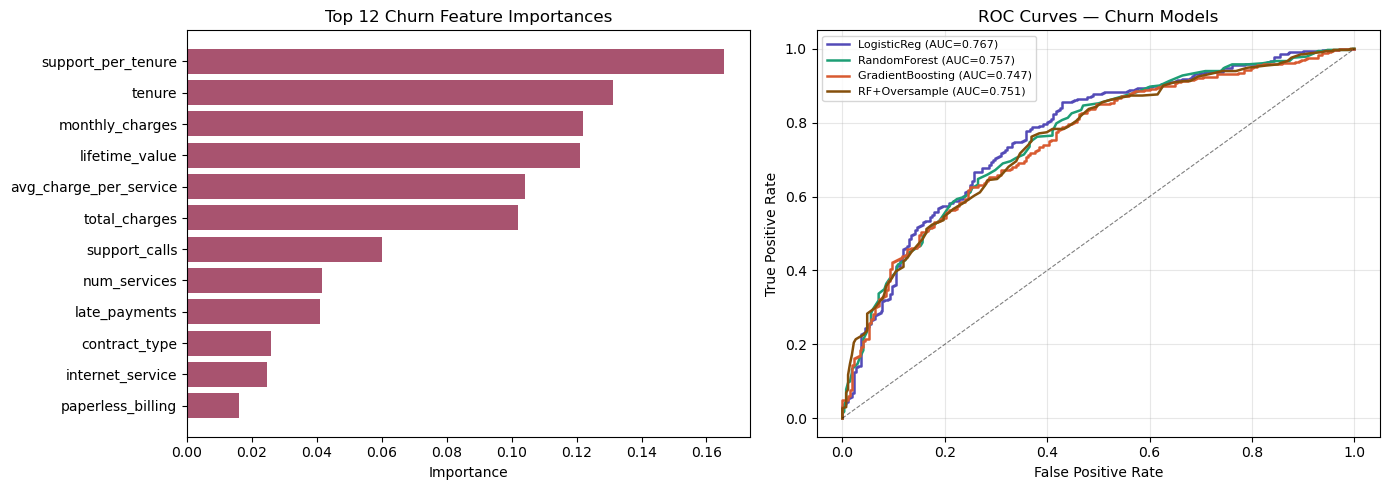

In [26]:
# ── 5.7  Feature Importance + Final Visualisation ────────────────────────────
rf_model = trained['RandomForest'][0]
imp_df   = pd.DataFrame({
    'feature'    : FEATURES,
    'importance' : rf_model.feature_importances_
}).sort_values('importance', ascending=True).tail(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
axes[0].barh(imp_df['feature'], imp_df['importance'], color='#993556', alpha=0.85)
axes[0].set_title('Top 12 Churn Feature Importances')
axes[0].set_xlabel('Importance')

# ROC curves for all models
colors_roc = ['#534AB7','#1D9E75','#D85A30','#854F0B']
for (name, (_, prob)), color in zip(trained.items(), colors_roc):
    fpr_, tpr_, _ = roc_curve(y_te_ch, prob)
    auc_ = roc_auc_score(y_te_ch, prob)
    axes[1].plot(fpr_, tpr_, color=color, linewidth=1.8, label=f'{name} (AUC={auc_:.3f})')
axes[1].plot([0,1],[0,1], 'k--', linewidth=0.8, alpha=0.5)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — Churn Models')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()